# Copilot

In [1]:
from datetime import datetime
from bs4 import BeautifulSoup
import pandas as pd
import re
import numpy as np
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Correct data

In [2]:
df1 = pd.read_csv(f'data/autoscout/{datetime.now().strftime("%y.%m.%d")}_autoscout_raw.csv')
# df1 = pd.read_csv(f'data/autoscout/24.05.14_autoscout_raw.csv')
df1['description'] = df1['title'] + ' ' + df1['description']
df1['location'] = df1['location'].str.extract(r'ES-\d+\s(.*)', expand=False)
df1['year'] = df1['year'].str.split('/').str[1]
df1['year'] = df1['year'].apply(lambda x: int(x) if x == x else np.nan)
df1 = df1.drop(['title', 'transmission'], axis=1)
df1['location'] = df1['location'].str.capitalize()
df1['brand'] = df1['brand'].str.capitalize()
df1

,brand,description,full_price,mileage,year,fuel,cv,location,url
0,Dacia,Dacia Dokker Comercial 1.6 GLP Ambiance N1 75kW,3333,325000,2018,Gas licuado (GLP),102,Sabadell,https://www.autoscout24.es/anuncios/dacia-dokk...
1,Citroen,Citroen Jumper Fg. 2.2HDI 30 L1H1 110,3500,205000,2016,Diésel,110,Galdakao,https://www.autoscout24.es/anuncios/citroen-ju...
2,Opel,Opel Crossland X 1.2T S&S Innovation 130,4199,73703,2019,Gasolina,131,Reus,https://www.autoscout24.es/anuncios/opel-cross...
3,Ford,Ford Transit FT 350 L3 Chasis Ambiente 125,4999,315000,2016,Diésel,125,Valencia,https://www.autoscout24.es/anuncios/ford-trans...
4,Renault,Renault Scenic Grand 1.6dCi eco2 Energy Bose 7pl.,5500,456000,2016,Diésel,131,Malaga,https://www.autoscout24.es/anuncios/renault-sc...
...,...,...,...,...,...,...,...,...,...
37015,Kia,Kia Ceed / cee'd PHEV 1.6 GDI PHEV EMOTION TOU...,27800,28970,2021,Otros,141,Sevilla,https://www.autoscout24.es/anuncios/kia-ceed-c...
37016,Cupra,CUPRA Formentor 1.5 TSI 150 DSG,27800,11754,2021,Gasolina,150,Motril,https://www.autoscout24.es/anuncios/cupra-form...
37017,Toyota,Toyota Corolla 140H GR Sport,27800,7399,2023,Electro/Gasolina,140,Córdoba,https://www.autoscout24.es/anuncios/toyota-cor...
37018,Cupra,CUPRA Formentor 1.5 TSI 150 DSG,27800,4340,2023,Gasolina,150,Huercal de almeria,https://www.autoscout24.es/anuncios/cupra-form...


In [3]:
df2 = pd.read_csv(f'data/flexicar/{datetime.now().strftime("%y.%m.%d")}_flexicar_raw.csv')
# df2 = pd.read_csv(f'data/flexicar/24.05.14_flexicar_raw.csv')
df2['cv'] = df2['description'].str.extract(r'\((\d+)CV\)', expand=False)
mask = pd.isna(df2['cv'])
df2['location'] = df2['city']
df2['location'] = df2['location'].str.capitalize()
df2.loc[mask, 'cv'] = df2.loc[mask, 'url'].str.extract(r'(\d+)(?:-cv|cv)(?!.*(?:-cv|cv))', expand=False)
df2['cv'] = df2['cv'].replace(np.nan, '0')
df2['cv'] = df2['cv'].astype(int)
df2['cv'] = df2['cv'].replace(0, np.nan)
df2['title'] = df2['title'].str.strip()
df2['description'] = df2['title'] + ' ' + df2['description']
df2['brand'] = df2['title'].str.split(' ').str[0]
df2['brand'] = df2['brand'].str.capitalize()
df2 = df2.drop(['title', 'discounted_price', 'monthly_rate', 'iva_deducible', 'offer', 'city', 'transmission'], axis=1)
df2

,full_price,description,year,mileage,fuel,url,cv,location,brand
0,NaN,Citroen C-Elysée BlueHDi 73KW (100CV) Shine,2017,139919,Diésel,https://www.flexicar.es//coches-ocasion/citroe...,100.0,Getafe-fuenlabrada,Citroen
1,8490.0,Citroen C3 Puretech 110cv Exclusive,2016,101707,Gasolina,https://www.flexicar.es//coches-ocasion/citroe...,110.0,Alcalá de henares,Citroen
2,NaN,Peugeot 208 BlueHDi 73kW (100CV) Active,2019,93468,Diésel,https://www.flexicar.es//coches-ocasion/peugeo...,100.0,Autosmadrid alcalá de henares,Peugeot
3,10490.0,Peugeot 2008 GT Line 1.2 PureTech 96KW (130CV)...,2016,187950,Gasolina,https://www.flexicar.es//coches-ocasion/peugeo...,130.0,Villalba 2,Peugeot
4,10790.0,Peugeot 3008 1.2 PURETECH 130 HP ALLURE S&S,2016,81753,Gasolina,https://www.flexicar.es//coches-ocasion/peugeo...,NaN,San fernando,Peugeot
...,...,...,...,...,...,...,...,...,...
1761,23190.0,Kia Sportage 1.6 MHEV Business 100kW (136CV) 4x4,2021,74126,Diésel,https://www.flexicar.es//coches-ocasion/kia-sp...,136.0,Autosmadrid leganés,Kia
1762,22990.0,Skoda Karoq 2.0 TDI 110kW (150CV) DSG 4X4 Ambi...,2019,114021,Diésel,https://www.flexicar.es//coches-ocasion/skoda-...,150.0,Autosmadrid móstoles,Skoda
1763,NaN,Land Rover Range Rover Evoque 2.0L eD4 Diesel ...,2018,45848,Diésel,https://www.flexicar.es//coches-ocasion/land-r...,150.0,Autosmadrid alcorcon,Land
1764,NaN,Ford Transit L3 H2,2019,52024,Diésel,https://www.flexicar.es//coches-ocasion/ford-t...,NaN,Getafe-fuenlabrada,Ford


In [4]:
df3 = pd.read_csv(f'data/ocasion/{datetime.now().strftime("%y.%m.%d")}_ocasion_raw.csv')
# df3 = pd.read_csv(f'data/ocasion/24.05.14_ocasion_raw.csv')
df3 = df3.loc[df3['status'] == 'Available']
df2['location'] = df2['location'].str.capitalize()
df3['description'] = df3['title'] + ' ' + df3['description']
df3['brand'] = df3['title'].str.split(' ').str[0]
df3['brand'] = df3['brand'].str.capitalize()
df3 = df3.drop(['title', 'discounted_price', 'discount', 'status', 'district', 'libro', 'warranty', 'owner', 'vista', 'transmission'], axis=1)
df3

,full_price,description,year,mileage,fuel,cv,location,url,brand
1,7900.0,Nissan X-TRAIL 1.6 dCi N-Connecta XTronic (130...,2016,323733,Diésel,130,Málaga,https://www.ocasionplus.com/coches-segunda-man...,Nissan
2,8350.0,Peugeot 3008 1.2 PureTech Style (130 CV),2016,181553,Gasolina,130,Barcelona,https://www.ocasionplus.com/coches-segunda-man...,Peugeot
5,8900.0,Opel Insignia Sports Tourer 1.6 CDTI S&S Busin...,2016,186300,Diésel,120,Pontevedra,https://www.ocasionplus.com/coches-segunda-man...,Opel
8,9300.0,Ford Focus 1.0 Ecoboost A-S-S 125 Business Spo...,2016,180860,Gasolina,125,Barcelona,https://www.ocasionplus.com/coches-segunda-man...,Ford
9,9700.0,Opel Adam .4 XER Slam(100 CV),2016,128167,Gasolina,100,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Opel
...,...,...,...,...,...,...,...,...,...
3358,57990.0,PLA GIOTTI 330 (140 CV),2021,9515,Diésel,140,Ciudad Real,https://www.ocasionplus.com/coches-segunda-man...,Pla
3359,58990.0,Volkswagen Transporter Mixto Batalla Corta TN ...,2021,30691,Diésel,150,Barcelona,https://www.ocasionplus.com/coches-segunda-man...,Volkswagen
3360,58990.0,Fiat Ducato 2.3 Multijet Maxi 35 Largo Techo A...,2019,42904,Diésel,150,Barcelona,https://www.ocasionplus.com/coches-segunda-man...,Fiat
3361,60500.0,McLouis MC4 379 MC4 379 (150CV),2019,139560,Diésel,150,La Coruña,https://www.ocasionplus.com/coches-segunda-man...,Mclouis


In [5]:
df4 = pd.read_csv(f'data/autocasion/{datetime.now().strftime("%y.%m.%d")}_autocasion_raw.csv')
# df4 = pd.read_csv(f'data/ocasion/24.05.14_ocasion_raw.csv')
df4['title'] = df4['title'].str.strip()
df4['description'] = df4['title']
df4['brand'] = df4['title'].str.split(' ').str[0]
df4['brand'] = df4['brand'].str.capitalize()
df4 = df4.drop(['title'], axis=1)
df4

,full_price,year,mileage,fuel,location,url,cv,description,brand
0,5500,2016,456000,Diésel,Málaga,https://www.autocasion.com/coches-segunda-mano...,130,RENAULT Scénic Grand 1.6dCi eco2 Energy Bose 7pl.,Renault
1,5650,2017,82000,Gasolina,Madrid,https://www.autocasion.com/coches-segunda-mano...,110,PEUGEOT 208 1.2 PureTech S&S GT Line EAT6 110 ...,Peugeot
2,5700,2017,431000,Diésel,Málaga,https://www.autocasion.com/coches-segunda-mano...,110,RENAULT Mégane S.T. 1.5dCi Energy Bose 81kW,Renault
3,5700,2018,300000,Diésel,Navarra,https://www.autocasion.com/coches-segunda-mano...,100,PEUGEOT 308 1.5BlueHDi S&S Access 100,Peugeot
4,5799,2021,48000,Gasolina,Tarragona,https://www.autocasion.com/coches-segunda-mano...,130,CITROEN C4 1.2 PureTech Shine S&S 130,Citroen
...,...,...,...,...,...,...,...,...,...
38736,49990,2017,40000,Diésel,Sevilla,https://www.autocasion.com/coches-segunda-mano...,136,MERCEDES-BENZ Clase V 200CDI Extralargo Avantg...,Mercedes-benz
38737,49990,2017,40000,Diésel,Málaga,https://www.autocasion.com/coches-segunda-mano...,136,MERCEDES-BENZ Clase V 200CDI Extralargo Avantg...,Mercedes-benz
38738,49990,2017,40000,Diésel,Cádiz,https://www.autocasion.com/coches-segunda-mano...,136,MERCEDES-BENZ Clase V 200CDI Extralargo Avantg...,Mercedes-benz
38739,49990,2023,7,Diésel,Madrid,https://www.autocasion.com/coches-km0/km-0/aud...,150,AUDI Q3 35 TDI S line S tronic 110kW,Audi


In [126]:
# Merge dfs
df2 = df2[df1.columns]
df3 = df3[df1.columns]
df4 = df4[df1.columns]
df = pd.concat([df2,df3,df4], ignore_index=True)
df['location'] = df['location'].str.lower().str.strip()
df = df.drop_duplicates()
df = df.dropna(subset=['full_price', 'cv'])
df['age'] = 2024 - df['year']
df = df.drop(['year'], axis=1)

# average_mileage_df = df.groupby('age')['mileage'].mean().reset_index()
# average_mileage_df.columns = ['age', 'average_mileage']

# average_price_df = df.groupby('age')['full_price'].mean().reset_index()
# average_price_df.columns = ['age', 'average_price']

# by_year_df = pd.merge(average_mileage_df, average_price_df, on='age')

# df = pd.merge(df, average_mileage_df, on='age', how='left')
# df['delta_mileage'] = df['mileage'] - df['average_mileage']

# df = df[df['full_price'] <= 15000]
df.drop_duplicates(subset=['brand', 'description', 'full_price', 'mileage', 'fuel', 'cv', 'age'], inplace=True)
df = df.reindex(columns=['fuel', 'brand', 'description', 'location', 'url', 'full_price', 'mileage', 'cv', 'age'])


In [17]:
# by_year_df['%'] = by_year_df['average_price']
# by_year_df

In [127]:
columns = ['full_price', 'mileage', 'cv', 'age']
for col in columns:
    mean = df[col].mean()
    std = df[col].std()
    
    # Define the upper and lower bounds
    lower_bound = mean - 3*std
    upper_bound = mean + 3*std
    
    # Filter the DataFrame
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
# df.to_csv(f'data/assembled/{datetime.now().strftime("%y.%m.%d")}_assembled.csv', index=False)

In [128]:
df['price_norm'] = -(df['full_price']-df['full_price'].mean())/(df['full_price'].std())
df['mileage_norm'] = -(df['mileage']-df['mileage'].mean())/(df['mileage'].std())
df['cv_norm'] = (df['cv']-df['cv'].mean())/(df['cv'].std())
df['age_norm'] = -(df['age']-df['age'].mean())/(df['age'].std())

df['rating'] = df['price_norm'] + df['mileage_norm'] + df['cv_norm'] + df['age_norm']

In [142]:
brands = ['Peugeot', 'Opel', 'Fiat', 'Citroen', 'Ford', 'Kia', 'Seat',
       'Dacia', 'Renault', 'Volkswagen', 'Hyundai', 'Skoda', 'Jeep',
       'Nissan', 'Abarth', 'Mazda', 'Audi', 'Infiniti', 'Cupra', 'Ds',
       'Alfa', 'Citroën', 'Mg', 'Ssangyong', 'Toyota',
       'Mitsubishi', 'Suzuki', 'Mini', 'Dfsk',
       'Subaru', 'Volvo', 'Iveco', 'Honda', 'Evo']

df_filter = df.loc[df['rating'] > 1.5]
df_filter = df_filter.loc[df_filter['age'] < 6]
df_filter = df_filter.loc[df_filter['mileage'] <= 100000]
df_filter = df_filter.loc[df_filter['brand'].isin(brands)]

In [143]:
df_filter.shape

(6548, 14)

In [144]:
df_filter.to_csv(f'data/assembled/{datetime.now().strftime("%y.%m.%d")}_assembled.csv', index=False)

In [135]:
brand_df = df_filter.groupby('brand').agg({
    'full_price': ['mean', 'count'],
    'cv': 'mean',
    'age': 'mean',
    'mileage': 'mean',
    'rating': 'mean'
}).reset_index()

# Flatten the MultiIndex columns
brand_df.columns = ['_'.join(col).strip() for col in brand_df.columns.values]

# Rename the columns
brand_df.rename(columns={
    'brand_': 'brand',
    'full_price_mean': 'average_price',
    'full_price_count': 'count',
    'cv_mean': 'average_cv',
    'age_mean': 'average_age',
    'mileage_mean': 'average_mileage',
}, inplace=True)

brand_df['value_rating'] = brand_df['rating_mean']/brand_df['average_price']

brand_df.sort_values(by='value_rating')

,brand,average_price,count,average_cv,average_age,average_mileage,rating_mean,value_rating
13,Mg,29730.000000,3,157.333333,1.333333,22556.666667,2.543533,0.000086
1,Audi,29122.500000,8,150.000000,1.000000,10354.125000,2.638399,0.000091
22,Subaru,30445.000000,2,153.000000,1.000000,3206.500000,2.776014,0.000091
12,Mazda,29377.500000,12,149.583333,1.000000,3593.083333,2.728479,0.000093
10,Jeep,28266.666667,3,154.000000,1.666667,9729.333333,2.703808,0.000096
3,Cupra,27672.471591,176,150.000000,1.056818,12681.153409,2.780437,0.000100
25,Volkswagen,26836.437500,48,149.166667,1.166667,14307.895833,2.769962,0.000103
15,Nissan,27491.516746,209,154.038278,1.325359,16197.100478,2.839614,0.000103
8,Honda,23345.000000,2,154.000000,3.000000,19757.500000,2.596176,0.000111
9,Hyundai,25835.615385,78,149.576923,1.205128,14150.820513,2.932724,0.000114


In [136]:
brand_df.sort_values(by='average_price')

,brand,average_price,count,average_cv,average_age,average_mileage,rating_mean,value_rating
16,Opel,19223.588235,51,135.352941,1.666667,19003.941176,2.773803,0.000144
24,Toyota,19294.444444,18,127.000000,1.111111,6573.777778,2.815178,0.000146
0,Abarth,20294.444444,9,148.333333,2.333333,30162.888889,2.807614,0.000138
21,Ssangyong,20432.307692,13,140.923077,1.846154,13665.076923,2.954553,0.000145
23,Suzuki,20528.125000,8,130.750000,1.125000,8677.750000,2.793767,0.000136
2,Citroen,20571.863636,66,132.318182,1.318182,13076.666667,2.688116,0.000131
4,Dacia,21428.862069,29,136.896552,1.482759,11746.379310,2.779941,0.000130
6,Fiat,21472.222222,9,140.666667,1.666667,15965.777778,2.813093,0.000131
17,Peugeot,22476.540541,37,133.297297,1.054054,6998.729730,2.718112,0.000121
8,Honda,23345.000000,2,154.000000,3.000000,19757.500000,2.596176,0.000111


In [65]:
df = df.drop(['age_norm', 'cv_norm', 'price_norm', 'mileage_norm'], axis=1)
df.to_csv(f'data/assembled/{datetime.now().strftime("%y.%m.%d")}_assembled.csv', index=False)

In [43]:
pd.set_option('display.max_colwidth', None)
df.sort_values(by='rating', ascending=True).head(30)

,fuel,brand,description,location,url,full_price,mileage,cv,age,price_norm,mileage_norm,cv_norm,age_norm,rating
42644,Diésel,Land-rover,LAND-ROVER Defender 110 SW SE,córdoba,https://www.autocasion.com/coches-segunda-mano/land-rover-defender-ocasion/defender-110-sw-se-1-ref7384485,39900.0,150000,122.0,8,-2.885624,-2.002523,-0.335888,-1.941624,-7.165660
42487,Diésel,Volkswagen,VOLKSWAGEN California 2.0TDI BMT Beach Edition Corto DSG 140,barcelona,https://www.autocasion.com/coches-segunda-mano/volkswagen-california-ocasion/2-0tdi-bmt-beach-edition-corto-dsg-140-ref12648859,38500.0,199000,140.0,8,-2.671355,-3.116863,0.728955,-1.941624,-7.000887
41539,Gasolina,Bmw,BMW Serie 1 116i,la coruña,https://www.autocasion.com/coches-segunda-mano/bmw-serie-1-ocasion/116i-13-ref11591656,35000.0,175000,109.0,6,-2.135682,-2.571064,-1.104942,-0.992375,-6.804063
41541,Diésel,Volkswagen,VOLKSWAGEN Caravelle 2.0TDI BMT Comfortline Ed.L 114,málaga,https://www.autocasion.com/coches-segunda-mano/volkswagen-caravelle-ocasion/caravelle-2-0tdi-bmt-comfortline-ed-l-114-ref13011525,35000.0,94000,114.0,8,-2.135682,-0.728993,-0.809152,-1.941624,-5.615452
28408,Gasolina,Mini,MINI Countryman ONE AUT.,la coruña,https://www.autocasion.com/coches-segunda-mano/mini-countryman-ocasion/mini-countryman-one-aut-2-ref12440202,22900.0,185568,102.0,6,-0.283785,-2.811397,-1.519048,-0.992375,-5.606605
39119,Diésel,Volkswagen,VOLKSWAGEN Caravelle 2.0TDI,valladolid,https://www.autocasion.com/coches-segunda-mano/volkswagen-caravelle-ocasion/2-0tdi-1665b311353ae5-ref13283985,30900.0,94626,105.0,8,-1.508180,-0.743229,-1.341574,-1.941624,-5.534607
27037,Diésel,Mercedes-benz,MERCEDES-BENZ Clase A 180CDI Aut.,alicante,https://www.autocasion.com/coches-segunda-mano/mercedes-benz-clase-a-ocasion/a-180cdi-autotronic-1-ref8035984,21999.0,206000,109.0,6,-0.145887,-3.276054,-1.104942,-0.992375,-5.519258
15749,Diésel,Audi,AUDI A3 Sedán 1.6TDI Design Edition S tronic 81kW,tarragona,https://www.autocasion.com/coches-segunda-mano/audi-a3-ocasion/a3-sedan-1-6tdi-design-edition-s-tronic-110-ref12197488,16700.0,201000,110.0,8,0.665121,-3.162346,-1.045784,-1.941624,-5.484633
6922,Gasolina,Ford,FORD Tourneo Connect 1.0 Ecoboost Trend,valencia,https://www.autocasion.com/coches-segunda-mano/ford-tourneo-connect-ocasion/tourneo-connect-1-0-ecoboost-trend-ref11454412,12600.0,202033,100.0,8,1.292623,-3.185838,-1.637364,-1.941624,-5.472203
4390,Diésel,Volkswagen,Volkswagen Caravelle Trendline Batalla Corta 2.0 TDI BMT (102 CV) 9 Plazas,madrid,https://www.ocasionplus.com/coches-segunda-mano/volkswagen-caravelle-trendline-corto-20-tdi-75kw102cv-bmt-con-115197km-2017,28990.0,115197,102.0,7,-1.215856,-1.211047,-1.519048,-1.467000,-5.412950


(array([3.000e+00, 0.000e+00, 1.000e+01, 2.800e+01, 1.460e+02, 4.280e+02,
        1.099e+03, 2.153e+03, 3.765e+03, 5.142e+03, 5.832e+03, 5.755e+03,
        5.526e+03, 4.406e+03, 2.713e+03, 1.189e+03, 2.270e+02, 7.000e+00,
        2.000e+00, 1.000e+00]),
 array([-7.1656602 , -6.51754974, -5.86943929, -5.22132883, -4.57321837,
        -3.92510791, -3.27699745, -2.62888699, -1.98077653, -1.33266607,
        -0.68455561, -0.03644515,  0.61166531,  1.25977577,  1.90788623,
         2.55599669,  3.20410715,  3.8522176 ,  4.50032806,  5.14843852,
         5.79654898]),
 <BarContainer object of 20 artists>)

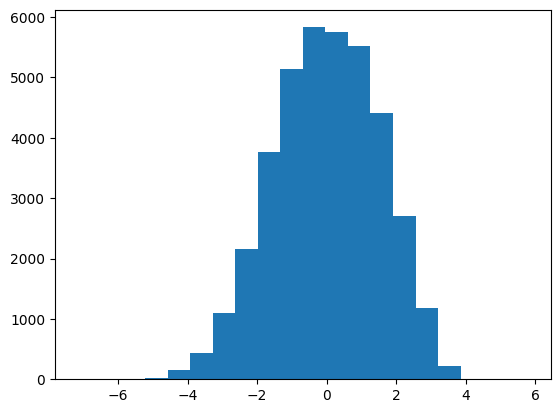

In [41]:
plt.hist(df.rating, bins=20)


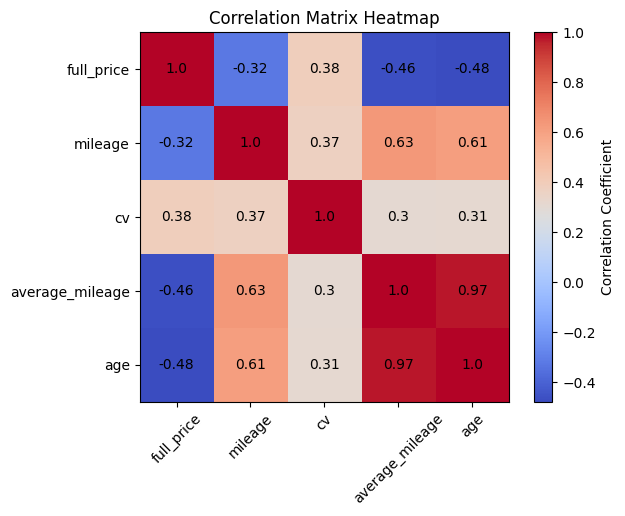

In [10]:
import numpy as np

spearman_matrix = df.drop(['brand', 'url', 'description', 'fuel', 'location'], axis=1).corr(method='spearman')
correlation_matrix = df.drop(['brand', 'url', 'description', 'fuel', 'location'], axis=1).corr()

plt.imshow(correlation_matrix, cmap='coolwarm')  # Adjust 'coolwarm' for preferred colormap

# Add labels and title
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(spearman_matrix.columns)), spearman_matrix.columns, rotation=45)
plt.yticks(range(len(spearman_matrix.columns)), spearman_matrix.columns)
plt.title('Correlation Matrix Heatmap')

# Add correlation numbers
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        text = plt.text(j, i, np.around(correlation_matrix.iloc[i, j], decimals=2),
                       ha="center", va="center", color="black")

# Display the plot
plt.show()
